# 01 - Experiment Design & Power Analysis

**Objective:** Before analyzing results, demonstrate proper experiment design.

This notebook covers:
1. Defining the hypothesis
2. Calculating minimum sample size using power analysis
3. Understanding the MDE vs sample size tradeoff
4. Documenting randomization approach

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Style settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

## 1. Business Context & Hypothesis

### The Problem
MetricFlow, a B2B SaaS analytics platform, has observed that many new signups fail to reach their "aha moment." The product team believes a guided onboarding experience could help users discover value faster.

### The Experiment
- **Control:** Self-serve onboarding (current experience)
- **Treatment:** Guided 3-step onboarding wizard

### Hypothesis

**Null Hypothesis (H₀):** The guided onboarding has no effect on 7-day activation rate.
$$H_0: p_{treatment} = p_{control}$$

**Alternative Hypothesis (H₁):** The guided onboarding increases 7-day activation rate.
$$H_1: p_{treatment} > p_{control}$$

(We use a one-sided test because we only care if the treatment is *better*, not just different.)

## 2. Key Parameters

Before running the experiment, we need to define:

In [2]:
# Historical baseline (from existing data)
BASELINE_CONVERSION_RATE = 0.30  # 30% of users activate within 7 days

# Statistical parameters
ALPHA = 0.05      # Significance level (Type I error rate)
POWER = 0.80      # Statistical power (1 - Type II error rate)

# Minimum Detectable Effect (MDE)
# This is a BUSINESS decision: what's the smallest lift worth detecting?
MDE_ABSOLUTE = 0.03  # 3 percentage points (30% → 33%)
MDE_RELATIVE = MDE_ABSOLUTE / BASELINE_CONVERSION_RATE  # ~10% relative lift

print(f"Baseline activation rate: {BASELINE_CONVERSION_RATE:.1%}")
print(f"Minimum Detectable Effect: {MDE_ABSOLUTE:.1%} absolute ({MDE_RELATIVE:.1%} relative)")
print(f"Target activation rate: {BASELINE_CONVERSION_RATE + MDE_ABSOLUTE:.1%}")
print(f"\nStatistical parameters:")
print(f"  α (significance level): {ALPHA}")
print(f"  Power (1-β): {POWER}")

Baseline activation rate: 30.0%
Minimum Detectable Effect: 3.0% absolute (10.0% relative)
Target activation rate: 33.0%

Statistical parameters:
  α (significance level): 0.05
  Power (1-β): 0.8


## 3. Sample Size Calculation

We need to determine how many users we need in each group to reliably detect our MDE.

### Formula Background
For comparing two proportions, the required sample size per group is:

$$n = \frac{(Z_{1-\alpha/2} + Z_{1-\beta})^2 \cdot (p_1(1-p_1) + p_2(1-p_2))}{(p_1 - p_2)^2}$$

Where:
- $p_1$ = control conversion rate
- $p_2$ = treatment conversion rate (baseline + MDE)
- $Z_{1-\alpha/2}$ = z-score for significance level
- $Z_{1-\beta}$ = z-score for power

In [3]:
def calculate_sample_size(baseline_rate, mde, alpha=0.05, power=0.80, two_sided=False):
    """
    Calculate required sample size per group for a two-proportion test.
    
    Parameters
    ----------
    baseline_rate : float
        Expected conversion rate in control group
    mde : float
        Minimum detectable effect (absolute)
    alpha : float
        Significance level
    power : float
        Statistical power
    two_sided : bool
        Whether to use two-sided test
        
    Returns
    -------
    int
        Required sample size per group
    """
    # Calculate effect size (Cohen's h for proportions)
    p1 = baseline_rate
    p2 = baseline_rate + mde
    effect_size = proportion_effectsize(p2, p1)
    
    # Use statsmodels power analysis
    analysis = NormalIndPower()
    
    # Calculate sample size
    n = analysis.solve_power(
        effect_size=effect_size,
        alpha=alpha,
        power=power,
        ratio=1.0,  # Equal group sizes
        alternative='two-sided' if two_sided else 'larger'
    )
    
    return int(np.ceil(n))

# Calculate for our parameters
sample_size_per_group = calculate_sample_size(
    baseline_rate=BASELINE_CONVERSION_RATE,
    mde=MDE_ABSOLUTE,
    alpha=ALPHA,
    power=POWER,
    two_sided=False  # One-sided test
)

total_sample_size = sample_size_per_group * 2

print(f"Required sample size per group: {sample_size_per_group:,}")
print(f"Total sample size needed: {total_sample_size:,}")

Required sample size per group: 2,964
Total sample size needed: 5,928


## 4. MDE vs Sample Size Tradeoff

There's a fundamental tradeoff: **smaller effects require larger samples to detect.**

Let's visualize this:

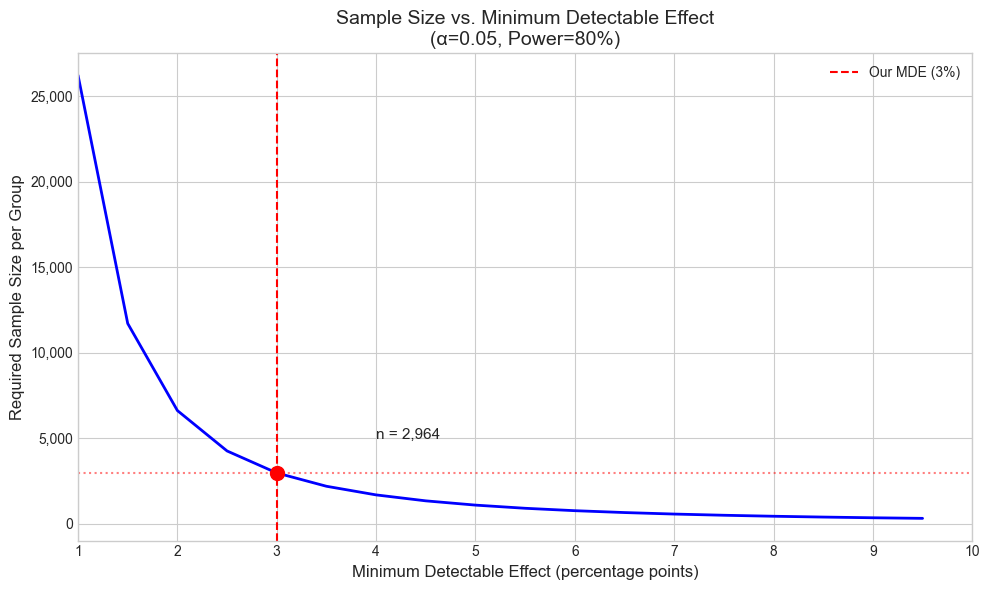


Key insight: Halving the MDE roughly quadruples the required sample size!


In [4]:
# Calculate sample sizes for different MDEs
mde_range = np.arange(0.01, 0.10, 0.005)  # 1% to 10% absolute
sample_sizes = []

for mde in mde_range:
    n = calculate_sample_size(
        baseline_rate=BASELINE_CONVERSION_RATE,
        mde=mde,
        alpha=ALPHA,
        power=POWER
    )
    sample_sizes.append(n)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(mde_range * 100, sample_sizes, 'b-', linewidth=2)
ax.axvline(x=MDE_ABSOLUTE * 100, color='red', linestyle='--', 
           label=f'Our MDE ({MDE_ABSOLUTE:.0%})')
ax.axhline(y=sample_size_per_group, color='red', linestyle=':', alpha=0.5)

# Mark our chosen point
ax.scatter([MDE_ABSOLUTE * 100], [sample_size_per_group], 
           color='red', s=100, zorder=5)
ax.annotate(f'n = {sample_size_per_group:,}', 
            xy=(MDE_ABSOLUTE * 100, sample_size_per_group),
            xytext=(MDE_ABSOLUTE * 100 + 1, sample_size_per_group + 2000),
            fontsize=11)

ax.set_xlabel('Minimum Detectable Effect (percentage points)', fontsize=12)
ax.set_ylabel('Required Sample Size per Group', fontsize=12)
ax.set_title('Sample Size vs. Minimum Detectable Effect\n(α=0.05, Power=80%)', fontsize=14)
ax.legend()
ax.set_xlim(1, 10)

# Format y-axis with thousands separator
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.show()

print("\nKey insight: Halving the MDE roughly quadruples the required sample size!")

## 5. Power vs Sample Size

What if we have a fixed sample size? Let's see what power we'd have:

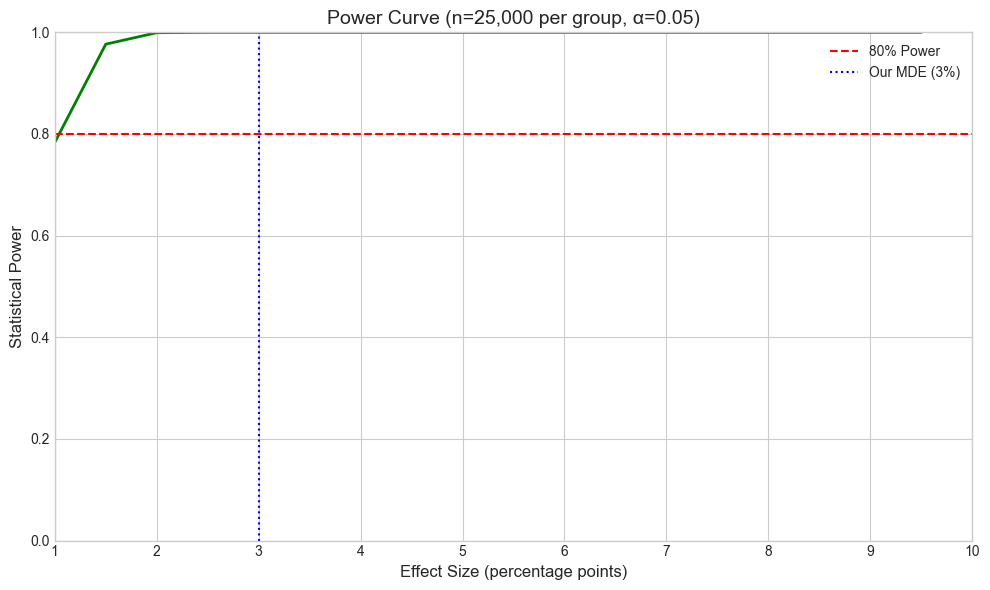


With n=25,000 per group and MDE=3%:
Statistical power = 100.0%


In [5]:
def calculate_power(baseline_rate, mde, sample_size, alpha=0.05):
    """Calculate statistical power given sample size."""
    p1 = baseline_rate
    p2 = baseline_rate + mde
    effect_size = proportion_effectsize(p2, p1)
    
    analysis = NormalIndPower()
    power = analysis.solve_power(
        effect_size=effect_size,
        nobs1=sample_size,
        alpha=alpha,
        ratio=1.0,
        alternative='larger'
    )
    return power

# Our actual sample size
ACTUAL_SAMPLE_SIZE = 25000  # per group

# Calculate power for different MDEs with our actual sample
powers = [calculate_power(BASELINE_CONVERSION_RATE, mde, ACTUAL_SAMPLE_SIZE) 
          for mde in mde_range]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(mde_range * 100, powers, 'g-', linewidth=2)
ax.axhline(y=0.80, color='red', linestyle='--', label='80% Power')
ax.axvline(x=MDE_ABSOLUTE * 100, color='blue', linestyle=':', 
           label=f'Our MDE ({MDE_ABSOLUTE:.0%})')

ax.set_xlabel('Effect Size (percentage points)', fontsize=12)
ax.set_ylabel('Statistical Power', fontsize=12)
ax.set_title(f'Power Curve (n={ACTUAL_SAMPLE_SIZE:,} per group, α=0.05)', fontsize=14)
ax.legend()
ax.set_ylim(0, 1)
ax.set_xlim(1, 10)

plt.tight_layout()
plt.show()

# Calculate our actual power
actual_power = calculate_power(BASELINE_CONVERSION_RATE, MDE_ABSOLUTE, ACTUAL_SAMPLE_SIZE)
print(f"\nWith n={ACTUAL_SAMPLE_SIZE:,} per group and MDE={MDE_ABSOLUTE:.0%}:")
print(f"Statistical power = {actual_power:.1%}")

## 6. Experiment Design Summary

### Randomization Unit
**User-level randomization** (not session-level)

**Why?**
- Onboarding is a one-time experience per user
- Session-level would cause the same user to see different experiences
- User-level ensures clean measurement of the treatment effect

### Assignment Method
- 50/50 split between control and treatment
- Hash-based assignment using user_id for consistency
- Assignment happens at signup time

### Guardrail Metrics
Beyond the primary metric (7-day activation), we should monitor:
1. **14-day activation** - longer-term effect
2. **Actions completed** - engagement depth
3. **Support tickets** - potential confusion

### Duration
- **Minimum:** Until we reach required sample size (~25K per group)
- **Recommended:** 4 weeks (to capture weekly patterns and novelty effects)

In [6]:
# Summary table
summary = pd.DataFrame({
    'Parameter': [
        'Primary Metric',
        'Baseline Rate',
        'Minimum Detectable Effect',
        'Significance Level (α)',
        'Statistical Power (1-β)',
        'Required Sample Size (per group)',
        'Total Sample Size',
        'Randomization Unit',
        'Test Duration'
    ],
    'Value': [
        '7-day activation rate',
        f'{BASELINE_CONVERSION_RATE:.0%}',
        f'{MDE_ABSOLUTE:.0%} ({MDE_RELATIVE:.0%} relative)',
        f'{ALPHA}',
        f'{POWER:.0%}',
        f'{sample_size_per_group:,}',
        f'{total_sample_size:,}',
        'User-level',
        '4 weeks'
    ]
})

print("\n" + "="*60)
print("EXPERIMENT DESIGN SUMMARY")
print("="*60)
print(summary.to_string(index=False))


EXPERIMENT DESIGN SUMMARY
                       Parameter                 Value
                  Primary Metric 7-day activation rate
                   Baseline Rate                   30%
       Minimum Detectable Effect     3% (10% relative)
          Significance Level (α)                  0.05
         Statistical Power (1-β)                   80%
Required Sample Size (per group)                 2,964
               Total Sample Size                 5,928
              Randomization Unit            User-level
                   Test Duration               4 weeks


---

## Next Steps

Now that we've designed the experiment, proceed to:

**→ Notebook 02: EDA & Randomization Validation**

We'll load the experiment data and verify that randomization worked correctly before analyzing results.